In [ ]:
import os
import numpy as np 
import pandas as pd 
import popgen
from scistreec_batch_cuda_vary_cnv import * # replaced with open-source scistreecna
from copy_number_tree_builder import construct_nj_tree_with_biopython
import scistree2 as s2
from other_tools import run_cellphy_reads
from simulation_custom import simulate # included in our open-source package
## 
from sklearn.metrics.pairwise import cosine_similarity
import pickle


def run_copy_num_nj(reads):
    copy_number_tree = construct_nj_tree_with_biopython(reads[:, :, 2])
    copy_number_tree = popgen.utils.from_newick(copy_number_tree)
    return copy_number_tree


def run_dice(reads):
    output_to_dice(reads)
    PATH = '/home/haz19024/miniconda3/envs/scistree2/bin/'
    os.system(f'PATH={PATH} dice -i dice_input.tsv -t -o dice_output -m balME')
    with open(f'dice_output/standard_root_balME_tree.nwk', 'r') as f:
        dice_nwk = f.readline().strip()
    dice_tree = popgen.utils.from_newick(dice_nwk)
    n_cell = len(dice_tree.get_leaves())
    dice_name_map = {f'leaf{i}': str(i) for i in range(n_cell)}
    dice_tree = popgen.utils.relabel(dice_tree, name_map=dice_name_map)
    return dice_tree


def run_cellphy(reads):
    cellphy_tree = run_cellphy_reads(reads)
    # cellphy_geno = get_cellphy_genotype('cellphy_tmp', tg)
    return cellphy_tree


def run_scistree2(reads):
    n_cell = reads.shape[1]
    gp = s2.probability.from_reads(reads[:, :, :2], cell_names=[f'{i}' for i in range(n_cell)], posterior=False)
    caller_spr = s2.ScisTree2(threads=8)
    tree_spr, imputed_genotype_spr, likelihood_spr = caller_spr.infer(gp)
    return tree_spr, imputed_genotype_spr.values


def run_scistree2_nj(reads):
    n_cell = reads.shape[1]
    gp = s2.probability.from_reads(reads[:, :, :2], cell_names=[f'{i}' for i in range(n_cell)], posterior=False)
    caller_spr = s2.ScisTree2(threads=8, nj=True)
    tree_spr, imputed_genotype_spr, likelihood_spr = caller_spr.infer(gp)
    return tree_spr, imputed_genotype_spr.values


def run_scistreec(reads, tree):
    n_site, n_cell, _ = reads.shape
    # cn_avg = estimate_copy_number(reads[:, :, -1], tree)
    s = ScisTreeC(CN_MAX=5, CN_MIN=1, LAMBDA_C=100, LAMBDA_S=1, LAMBDA_T=2*n_cell-1, verbose=False)
    probs = s.init_prob_leaves_gpu(reads, cnerr=0.05, af=0.5)
    ctree, ml = s.local_search_batch(probs, tree)
    ml2, indices = s.marginal_evaluate_dp(probs, ctree)
    scistreec_geno = construct_genotype(ctree, indices)
    sites = [_ for _ in range(n_site)]
    decoded_trees = s.viterbi_decoding(probs, ctree, sites)
    tt = find_copy_gain_loss_on_branch(decoded_trees) 
    return ctree, scistreec_geno, tt



def add_noise(reads, cnerr=0.05):
    reads, masks = add_copy_number_noise2(reads, noise_prob=cnerr) # add noise to copy numbers
    reads[reads[:, :, 2] > 5] = 5
    return reads


def load_missionbio_data(prefix):
    reads = np.load(f'{prefix}.npy')
    return reads




tskit not found.
tskit not found.


In [2]:
data_path = './missionbio/3_mixed_subsample_200'
reads = load_missionbio_data(data_path)
reads = np.transpose(reads, (1, 0, 2))
reads = reads.astype(int)


# creads = reads.copy()
# creads[creads > 100] = 100
# cellphy_tree = run_cellphy(creads)
# dice_tree = run_dice(reads)
# nj_tree = run_copy_num_nj(reads)
# snj_tree, _ = run_scistree2_nj(reads)
# scistree2_tree, scistree2_geno = run_scistree2(reads) 


# load scistreec tree
with open('3_mixed_cell_scistreec_results_2.pkl', 'rb') as f:
    res = pickle.load(f)
scistree2_tree = res['scistree2_tree']
scistree2_geno = res['scistree2_geno']
scistreec_tree = res['scistreec_tree']
scistreec_geno = res['scistreec_geno']
decoded_tree = res['decoded_tree']
sample = res['data']




/home/haz19024/miniconda3/envs/mosaic/lib/python3.11/site-packages/missionbio/mosaic/io.py:47: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
# scistreec_tree3, scistreec_geno3, decoded_tree3 = run_scistreec(reads, scistree2_tree) 

new tree evaluated -182489.4454345703 new tree evaluated -182465.3712158203 new tree evaluated -182440.3826904297 new tree evaluated -182417.15771484375 new tree evaluated -182391.22790527344 new tree evaluated -182370.24951171875 new tree evaluated -182346.03515625 new tree evaluated -182325.23022460938 new tree evaluated -182295.2459716797 new tree evaluated -182265.1220703125 new tree evaluated -182245.00366210938 new tree evaluated -182226.65783691406 new tree evaluated -182205.30395507812 new tree evaluated -182191.83203125 new tree evaluated -182180.4501953125 new tree evaluated -182170.29040527344 new tree evaluated -182159.52111816406 new tree evaluated -182148.951171875 new tree evaluated -182139.02026367188 new tree evaluated -182129.81774902344 new tree evaluated -182120.93225097656 new tree evaluated -182112.13317871094 new tree evaluated -182102.8165283203 new tree evaluated -182092.57849121094 new tree evaluated -182084.1063232422 new tree evaluated -182076.1973876953 new

In [ ]:
# save scistreec tree
# with open('3_mixed_cell_scistreec_results_2.pkl', 'wb') as out:
#     pickle.dump({'scistree2_tree': scistree2_tree, 'scistree2_geno': scistree2_geno, 'scistreec_tree': scistreec_tree3, 'scistreec_geno': scistreec_geno3, 'decoded_tree': decoded_tree3, 'data': sample}, out)

In [3]:
# see decoded tree 
def run_scistreec_decode(reads, tree):
    n_site, n_cell, _ = reads.shape
    cn_avg = estimate_copy_number(reads[:, :, -1], tree)
    s = ScisTreeC(CN_MAX=5, CN_MIN=1, LAMBDA_C=100, LAMBDA_S=1, LAMBDA_T=2*n_cell-1, verbose=False)
    probs = s.init_prob_leaves_gpu(reads, cnerr=0.05, af=0.5)
    sites = [_ for _ in range(n_site)]
    decoded_trees = s.viterbi_decoding(probs, tree, sites)
    return decoded_trees

gene_names = sample.dna.col_attrs['id']
decoded_trees = run_scistreec_decode(reads, scistreec_tree)

In [19]:
def find_copy_gain_loss_on_branch(decoded_trees, gene_names=None):
    if gene_names is None:
        gene_names = [f'gene_{i}' for i in range(len(decoded_trees))]
    traversor = popgen.utils.TraversalGenerator()
    tree = decoded_trees[0].copy() # a fresh tree
    for node in traversor(tree):
        node.events = {'loss': [], 'gain': []}
    for d_tree, gene_name in zip(decoded_trees, gene_names):
        for node in traversor(d_tree):
            if node.is_root():
                if node.cn[1] != 0:
                    tree[node.name].events['gain'].append(f'{gene_name}:({node.cn[0]}: {node.cn[1]})')
            else:
                if node.cn[1] > node.parent.cn[1]:
                    tree[node.name].events['gain'].append(f'{gene_name}:({node.cn[0]}: {node.cn[1]})')
                if node.cn[1] < node.parent.cn[1] and node.cn[1] == 0:
                    tree[node.name].events['loss'].append(f'{gene_name}:({node.cn[0]}: {node.cn[1]})')
    return tree

decoded_tree = find_copy_gain_loss_on_branch(decoded_trees, gene_names)

In [107]:
def _bfs(node, site_index, state_index):
        cn_profile = s.cn_profile_at_index(state_index)
        node.cn3 = cn_profile
        if not node.is_leaf():
            for child in node.get_children():
                child_state_index = node.arg[child.identifier][site_index][state_index]
                _bfs(child, site_index, int(child_state_index))

_bfs(decoded_trees[11].root, 11, s.index_gt(1,1))

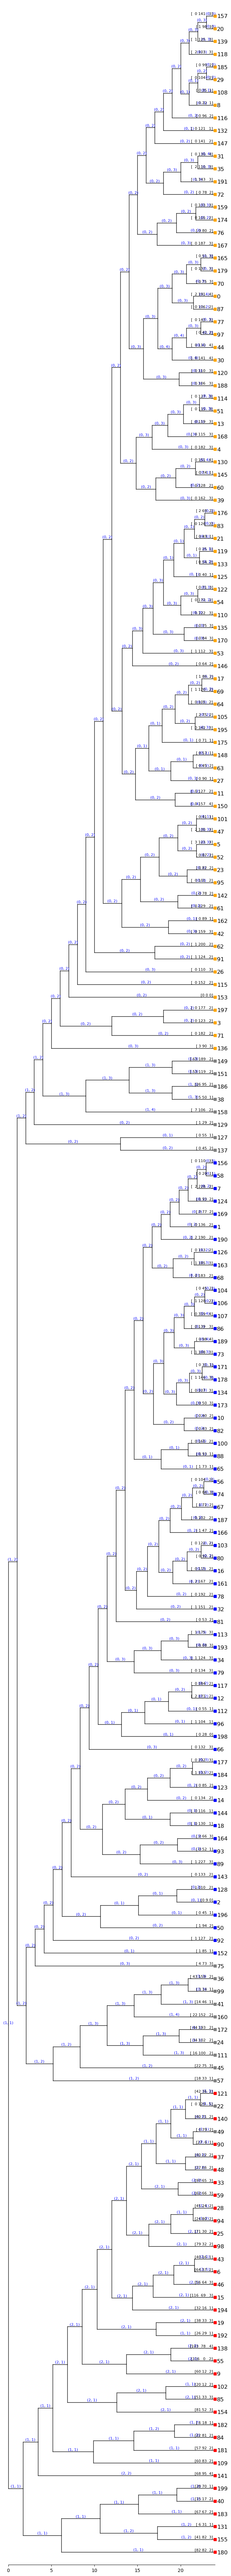

In [18]:

ii = 11
colors = {'Jurkat': 'blue', 'KG-1': 'orange', 'TOM-1': 'red', 'Mixed': 'grey'}
tv = TreeViz(decoded_trees[ii].output())
traversor = popgen.utils.TraversalGenerator()
for node in traversor(decoded_trees[ii]):
    leaves = [leaf.name for leaf in node.get_leaves()]
    tv.text_on_branch(leaves, node.cn, xpos='center', ypos='top', color='blue')


# tv.show_branch_length(color='red', label_formatter=lambda v: f"#mut: {v:.2f}")
# tv.show_confidence(color='blue', label_formatter=lambda v: f"conf: {v:.2f}")

for leaf in decoded_trees[ii].get_leaves():
    leaf = decoded_trees[ii][leaf]
    label = sample.dna.row_attrs['label'][int(leaf.name)]
    tv.marker(leaf.name, marker="s", color=colors[label])
    tv.text_on_branch(leaf.name, reads[ii][int(leaf.name)])


tv.show_scale_axis()
fig = tv.plotfig()

In [12]:
decoded_tree.output(branch_length_func=lambda x: 1 + len(x.events['gain']) + len(x.events['loss']))

'((((((((((((((((((((((((157:4,20:4):3,139:1):1,118:2):3,(((185:2,29:5):2,108:1):3,8:2):2):3,116:3):2,132:7):1,147:3):2,(((31:5,35:1):3,191:4):4,72:1):2):3,(((159:3,174:3):1,76:2):1,167:2):2):1,(((((165:3,179:4):3,70:2):1,(0:3,87:4):2):2,(((77:3,97:5):3,44:2):4,30:1):4):2,(120:3,188:3):1):3):1,(((((114:1,51:2):3,13:1):2,168:4):2,4:2):2,(((130:4,145:3):3,60:1):1,39:5):2):2):1,(((((((((176:4,83:3):3,21:1):2,(119:1,133:5):2):4,125:4):2,((122:6,54:6):2,110:3):3):3,(135:3,170:4):1):1,53:4):4,146:2):2,((((((17:4,69:2):3,64:1):3,(105:3,195:4):3):4,175:5):2,((148:1,63:4):3,27:1):1):4,(11:1,150:4):3):2):2):2,(((((101:4,47:4):3,(52:2,5:4):2):1,(23:3,95:3):1):1,(142:1,61:2):2):1,(162:2,42:5):1):3):1,(62:1,91:4):2):1,26:4):2,115:1):1,153:2):2,((197:4,3:5):3,71:5):3):3,136:6):6,(((149:2,151:2):1,(186:2,38:4):3):2,158:3):5):3,129:1):4,(127:4,137:1):4):11,(((((((((((((((((((((156:4,58:4):1,7:1):2,124:3):2,169:4):3,1:2):2,190:2):1,((126:4,163:3):2,68:2):1):1,((((((104:3,106:3):3,107:6):2,86:5):1,(189:

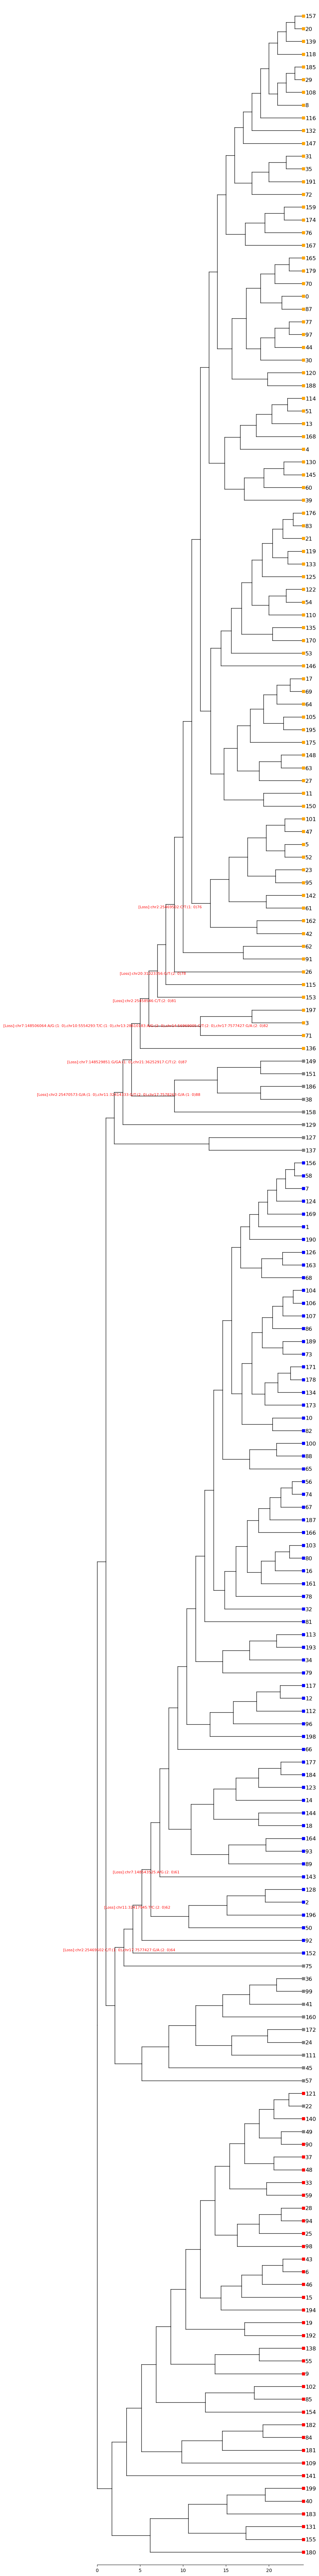

In [20]:
anns = sample.dna.get_annotations()
anns['gid'] = anns.apply(lambda x: x['Gene'] + ':' + x['Ref allele'] + ':' +  x['Alt allele'], axis=1)
gene_mapping = {f'gene_{i}': gene for i, gene in enumerate(anns['gid'])}
# gene_mapping = {f'gene_{i}': gene for i, gene in enumerate(anns.index)}

colors = {'Jurkat': 'blue', 'KG-1': 'orange', 'TOM-1': 'red', 'Mixed': 'grey'}
tv = TreeViz(decoded_tree.output())
traversor = popgen.utils.TraversalGenerator()
for node in traversor(decoded_tree):
    leaves = [leaf.name for leaf in node.get_leaves()]
    if len(leaves) < 10:
        continue
    # print(node.events)
    # if node.events['gain']:
    #     gain_annotation = '[Gain]:' + ','.join([gene for gene in node.events['gain']]) 
    #     tv.text_on_branch(leaves, gain_annotation, xpos='center', ypos='top', color='blue')
    if node.events['loss']:
        loss_annotation = '[Loss]:' + ','.join([gene for gene in node.events['loss']] ) + str(len(leaves))
        tv.text_on_branch(leaves, loss_annotation, xpos='center', ypos='bottom', color='red')
# tv.show_branch_length(color='red', label_formatter=lambda v: f"#mut: {v:.2f}")
# tv.show_confidence(color='blue', label_formatter=lambda v: f"conf: {v:.2f}")

for leaf in decoded_tree.get_leaves():
    leaf = decoded_tree[leaf]
    label = sample.dna.row_attrs['label'][int(leaf.name)]
    tv.marker(leaf.name, marker="s", color=colors[label])


tv.show_scale_axis()
fig = tv.plotfig()

In [14]:
sample.dna.col_attrs['id']


array(['chr2:25458546:C/T', 'chr2:25469502:C/T', 'chr2:25470426:C/T',
       'chr2:25470573:G/A', 'chr2:209113192:G/A', 'chr4:55599436:T/C',
       'chr4:106154990:TATAGATAG/T', 'chr4:106154990:T/TATAG',
       'chr4:106158216:G/A', 'chr4:106190862:T/C', 'chr4:106197469:G/A',
       'chr6:62094287:A/T', 'chr7:148506064:A/G', 'chr7:148529851:G/GA',
       'chr7:148543525:A/G', 'chr10:5554293:T/C', 'chr10:77210191:C/T',
       'chr10:106721610:G/A', 'chr11:32414333:G/T', 'chr11:32417945:T/C',
       'chr12:112888239:C/T', 'chr13:28597686:G/A', 'chr13:28610183:A/G',
       'chr14:56969005:C/T', 'chr17:7577427:G/A', 'chr17:7578176:C/T',
       'chr17:7578263:G/A', 'chr20:31023356:G/T', 'chr21:36252917:C/T'],
      dtype=object)

In [21]:
sample.dna.add_row_attr('cid', np.arange(200))

In [22]:
# calculate centroid of KG-1, TOM-1 and Jurkat
center_j = sample.dna[sample.dna.barcodes('Jurkat'), :].layers['AF'].mean(axis=0)
center_t = sample.dna[sample.dna.barcodes('TOM-1'), :].layers['AF'].mean(axis=0)
center_k = sample.dna[sample.dna.barcodes('KG-1'), :].layers['AF'].mean(axis=0)

center_jt = (center_j + center_t) / 2
center_jk = (center_j + center_k) / 2
center_kt = (center_k + center_t) / 2

cids = sample.dna[sample.dna.barcodes('Mixed'), :].row_attrs['cid']
vafs = sample.dna[sample.dna.barcodes('Mixed'), :].layers['AF']
for cid, vaf in zip(cids, vafs):
    sim_j = cosine_similarity([vaf], [center_j])[0][0]
    sim_t = cosine_similarity([vaf], [center_t])[0][0]
    sim_k = cosine_similarity([vaf], [center_k])[0][0]
    sim_jt = cosine_similarity([vaf], [center_jt])[0][0]
    sim_jk = cosine_similarity([vaf], [center_jk])[0][0]
    sim_kt = cosine_similarity([vaf], [center_kt])[0][0]
    # print(cid, sim_j, sim_k, sim_t)
    print(cid, sim_jt, sim_jk, sim_kt)

22 0.7707503711706193 0.5725454497076709 0.6194963180692887
24 0.977763036022991 0.7914996907863684 0.7123002456025984
36 0.9802027212641214 0.7980751911388896 0.7593119436549131
38 0.7588358953909684 0.8375003281654573 0.9538217909419004
41 0.990603781173034 0.7819785594586355 0.7625537254217467
45 0.9751498287003494 0.7982275663814162 0.7267780933718013
49 0.8550037912362711 0.6998501732462514 0.7993590146634553
57 0.9748595441047659 0.7710921185360092 0.7989708900609959
75 0.947547877941939 0.8231390315499305 0.6946147863824459
99 0.9391798295930258 0.7819960882483443 0.8074646225147513
111 0.9465166982956855 0.7729016498307616 0.6921250729384153
127 0.8194425775680703 0.9079105505190873 0.6934090822907386
129 0.7653281114247725 0.8862690320264996 0.8217164052834998
137 0.8304900252740665 0.9237822335697115 0.7370155672625209
149 0.6864803227440889 0.8694156492099544 0.9771473663719781
151 0.7411967237772058 0.8399811504069393 0.9749437639065452
158 0.6829813457831697 0.858667591022

In [18]:
sample.dna.scatterplot(attribute='umap', colorby='label')

FigureWidget({
    'data': [{'customdata': array([['label: KG-1<br>GACGCTTGCCATACGCAG'],
                                   ['label: KG-1<br>TAACATTGGCTTGGTCAT'],
                                   ['label: KG-1<br>TAACATTGGTCCGATAAC'],
                                   ['label: KG-1<br>CCGGTTCTAGCTTACGTT'],
                                   ['label: KG-1<br>AGATCGAGTGAGACTCGA'],
                                   ['label: KG-1<br>TGAACCAATCCTTGTTGC'],
                                   ['label: KG-1<br>GTAGTTGGTACTAACCGA'],
                                   ['label: KG-1<br>TACGTTACCCATTGTTCA'],
                                   ['label: KG-1<br>CTGAGTCCATCAGACAAG'],
                                   ['label: KG-1<br>TACAGTTAGTTGTCAACC'],
                                   ['label: KG-1<br>GTCAGCGTCTTCCAATTC'],
                                   ['label: KG-1<br>GTTGCATGGCGGTAGCTT'],
                                   ['label: KG-1<br>CGGTCGACAAACTAACTG'],
                       

In [21]:
decoded_tree.output(branch_length_func=lambda x: len(x.events['gain']) + len(x.events['loss'])+1)

'((((((((((((((((((((((((157:1,20:10):1,139:1):1,118:1):1,(((185:1,29:10):1,108:1):1,8:1):1):1,116:1):1,132:10):1,147:1):1,(((31:1,35:1):1,191:1):1,72:1):1):10,(((159:1,174:10):1,76:1):1,167:1):1):1,(((((165:1,179:10):1,70:1):1,(0:1,87:1):1):1,(((77:1,97:1):1,44:1):1,30:1):1):1,(120:1,188:1):1):1):1,(((((114:1,51:1):1,13:1):1,168:1):1,4:1):1,(((130:1,145:1):1,60:1):1,39:1):1):1):1,(((((((((176:1,83:1):1,21:1):1,(119:1,133:1):1):1,125:1):1,((122:1,54:10):1,110:1):1):1,(135:1,170:1):1):1,53:10):1,146:10):1,((((((17:1,69:1):10,64:1):1,(105:1,195:10):1):1,175:10):1,((148:1,63:1):1,27:1):1):1,(11:1,150:1):1):1):1):1,(((((101:1,47:1):10,(52:1,5:1):1):1,(23:1,95:1):1):1,(142:1,61:1):1):1,(162:1,42:1):1):1):1,(62:1,91:10):1):1,26:1):1,115:1):1,153:1):1,((197:1,3:10):1,71:10):1):1,136:1):13,(((149:1,151:1):1,(186:1,38:1):1):1,158:1):1):9,129:1):1,(127:1,137:1):13):10,(((((((((((((((((((((156:1,58:1):1,7:1):1,124:1):1,169:1):1,1:1):1,190:1):1,((126:1,163:1):1,68:1):1):1,((((((104:1,106:1):9,107:

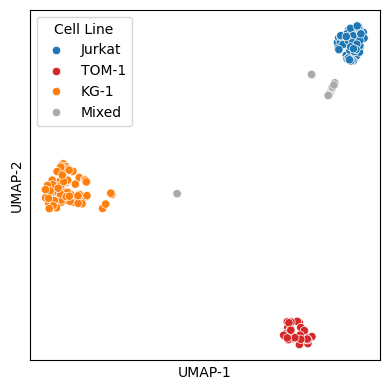

In [17]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt 
color_map = {
    'TOM-1': '#d62728', # red
    'Jurkat': '#1f77b4', # blue
    'KG-1': '#ff7f0e', # green
    'Mixed': '#AAAAAA'  # grey
    # ... add all your other classes
}
color_palette = ['#1f77b4', '#d62728', '#ff7f0e', '#AAAAAA']
umap_data = sample.dna.row_attrs['umap']
umap_df = pd.DataFrame(umap_data)
umap_df['label'] = sample.dna.row_attrs['label']
fig, ax = plt.subplots( figsize=(4, 4), nrows=1, ncols=1)
sns.scatterplot(data=umap_df, x=0, y=1, hue='label', palette=color_palette, hue_order=['Jurkat', 'TOM-1', 'KG-1', 'Mixed'], ax=ax)
ax.set_ylabel('UMAP-2')
ax.set_xlabel('UMAP-1')
ax.legend_.set_title('Cell Line')
# plt.axis('off')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.savefig('figures/umap.png', dpi=500)


In [8]:
sample.dna.heatmap(attribute='AF').show("jpg")

FigureWidget({
    'data': [{'colorscale': [[0.0, '#1f77b4'], [0.25, '#1f77b4'], [0.25,
                             '#ff7f0e'], [0.5, '#ff7f0e'], [0.5, '#c7c7c7'], [0.75,
                             '#c7c7c7'], [0.75, '#d62728'], [1.0, '#d62728']],
              'hoverinfo': 'skip',
              'name': 'labels',
              'showlegend': False,
              'showscale': False,
              'type': 'heatmap',
              'uid': 'ef9babca-f045-4799-9036-8ef1fb719ddc',
              'x': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                    0

In [9]:
sample.dna.scatterplot(attribute='umap', colorby='label').show('jpg')

FigureWidget({
    'data': [{'customdata': array([['label: KG-1<br>GACGCTTGCCATACGCAG'],
                                   ['label: KG-1<br>TAACATTGGCTTGGTCAT'],
                                   ['label: KG-1<br>TAACATTGGTCCGATAAC'],
                                   ['label: KG-1<br>CCGGTTCTAGCTTACGTT'],
                                   ['label: KG-1<br>AGATCGAGTGAGACTCGA'],
                                   ['label: KG-1<br>TGAACCAATCCTTGTTGC'],
                                   ['label: KG-1<br>GTAGTTGGTACTAACCGA'],
                                   ['label: KG-1<br>TACGTTACCCATTGTTCA'],
                                   ['label: KG-1<br>CTGAGTCCATCAGACAAG'],
                                   ['label: KG-1<br>TACAGTTAGTTGTCAACC'],
                                   ['label: KG-1<br>GTCAGCGTCTTCCAATTC'],
                                   ['label: KG-1<br>GTTGCATGGCGGTAGCTT'],
                                   ['label: KG-1<br>CGGTCGACAAACTAACTG'],
                       

In [29]:
sample.dna.get_annotations()

,Position,Ref allele,Alt allele,Varsome url,Variant type,RefSeq transcript id,Gene,Protein,cDNA,Coding impact,Function,Allele Freq (gnomAD),DANN,dbSNP rsids,ClinVar,COSMIC ids
Variant ID,,,,,,,,,,,,,,,,
chr2:25458546:C/T,25458546,C,T,https://varsome.com/variant/hg19/chr2:25458546...,SNV,NM_022552.5,DNMT3A,DNMT3A:p.p.?,c.2597+30G>A,,intronic,0.513776,0.551042,rs2304429,Benign,
chr2:25469502:C/T,25469502,C,T,https://varsome.com/variant/hg19/chr2:25469502...,SNV,NM_022552.5,DNMT3A,DNMT3A:p.L422=,c.1266G>A,synonymous,coding,0.190004,0.802194,rs2276598,Benign,
chr2:25470426:C/T,25470426,C,T,https://varsome.com/variant/hg19/chr2:25470426...,SNV,NM_022552.5,DNMT3A,DNMT3A:p.p.?,c.1014+34G>A,,intronic,0.000702,0.635212,rs142243425,,
chr2:25470573:G/A,25470573,G,A,https://varsome.com/variant/hg19/chr2:25470573...,SNV,NM_022552.5,DNMT3A,DNMT3A:p.R301W,c.901C>T,missense,coding,,0.999237,rs1553414070,Conflicting Interpretations Of Pathogenicity,
chr2:209113192:G/A,209113192,G,A,https://varsome.com/variant/hg19/chr2:20911319...,SNV,NM_005896.4,IDH1,IDH1:p.G105=,c.315C>T,synonymous,coding,0.05057,0.680929,rs11554137,Benign,
chr4:55599436:T/C,55599436,T,C,https://varsome.com/variant/hg19/chr4:55599436...,SNV,NM_000222.3,KIT,KIT:p.p.?,c.2484+78T>C,,intronic,,0.562532,rs1008658,Benign,
chr4:106154990:TATAGATAG/T,106154991,ATAGATAG,,https://varsome.com/variant/hg19/chr4:10615499...,Deletion,NM_001127208.3,TET2,TET2:p.p.?,c.-46-46_-46-39del,,intronic,,,rs58201766,Benign,
chr4:106154990:T/TATAG,106154991,,ATAG,https://varsome.com/variant/hg19/chr4:10615499...,Insertion,NM_001127208.3,TET2,TET2:p.p.?,c.-46-42_-46-39dup,,intronic,,,rs58201766,,
chr4:106158216:G/A,106158216,G,A,https://varsome.com/variant/hg19/chr4:10615821...,SNV,NM_001127208.3,TET2,TET2:p.S1039=,c.3117G>A,synonymous,coding,0.032105,0.587786,rs3796927,Benign,


In [10]:
import missionbio.mosaic as ms
wfc = ms.workflows.CopyNumber(sample)
wfc.run()

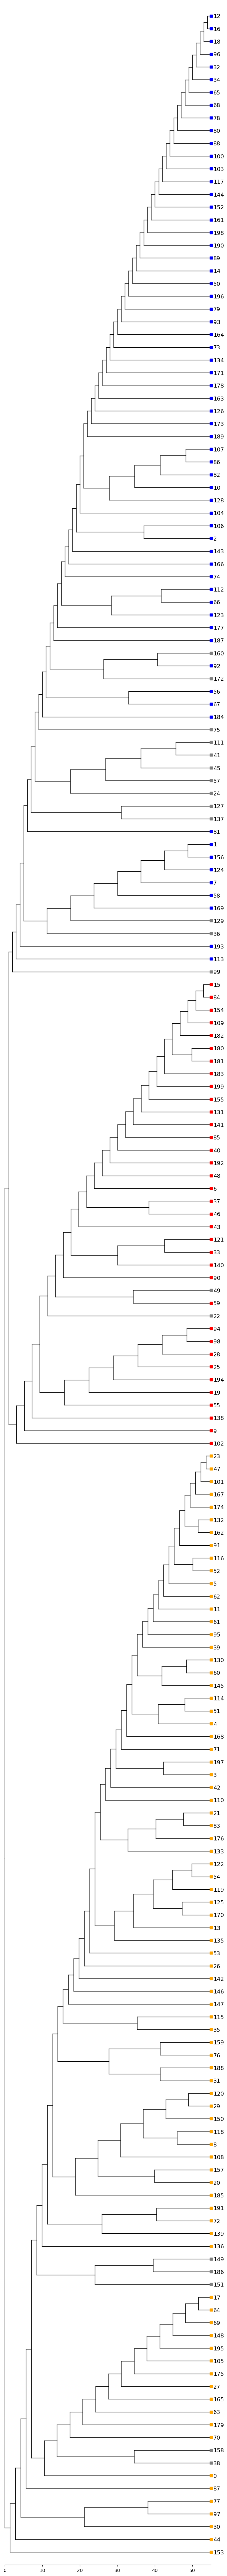

In [37]:
# plot cellphy
colors = {'Jurkat': 'blue', 'KG-1': 'orange', 'TOM-1': 'red', 'Mixed': 'grey'}
tv = TreeViz(scistree2_tree.output())
traversor = popgen.utils.TraversalGenerator()

# tv.show_branch_length(color='red', label_formatter=lambda v: f"#mut: {v:.2f}")
# tv.show_confidence(color='blue', label_formatter=lambda v: f"conf: {v:.2f}")

for leaf in scistree2_tree.get_leaves():
    leaf = scistree2_tree[leaf]
    label = sample.dna.row_attrs['label'][int(leaf.name)]
    tv.marker(leaf.name, marker="s", color=colors[label])

tv.show_scale_axis()
fig = tv.plotfig()

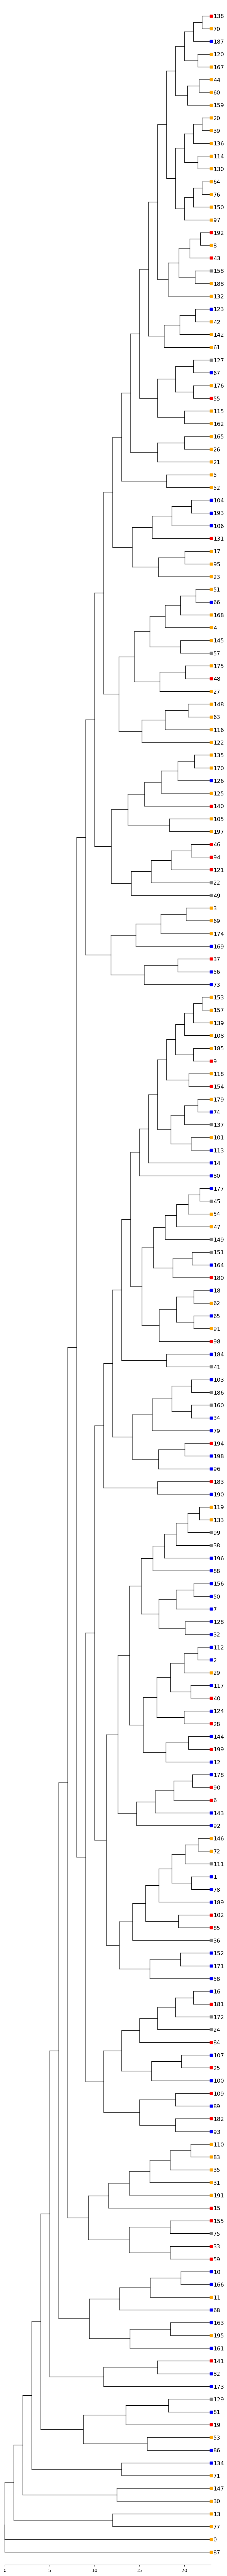

In [54]:
# plot nj 
colors = {'Jurkat': 'blue', 'KG-1': 'orange', 'TOM-1': 'red', 'Mixed': 'grey'}
tv = TreeViz(dice_tree.output())
traversor = popgen.utils.TraversalGenerator()

# tv.show_branch_length(color='red', label_formatter=lambda v: f"#mut: {v:.2f}")
# tv.show_confidence(color='blue', label_formatter=lambda v: f"conf: {v:.2f}")

for leaf in dice_tree.get_leaves():
    leaf = dice_tree[leaf]
    label = sample.dna.row_attrs['label'][int(leaf.name)]
    tv.marker(leaf.name, marker="s", color=colors[label])

tv.show_scale_axis()
fig = tv.plotfig()

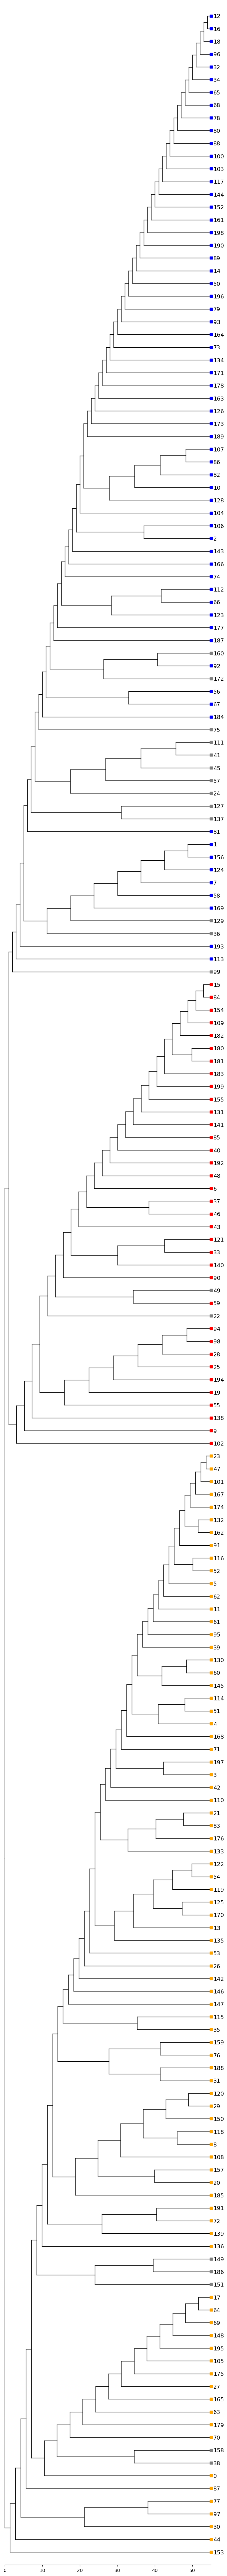

In [55]:
# plot scistree2 
colors = {'Jurkat': 'blue', 'KG-1': 'orange', 'TOM-1': 'red', 'Mixed': 'grey'}
tv = TreeViz(scistree2_tree.output())
traversor = popgen.utils.TraversalGenerator()

# tv.show_branch_length(color='red', label_formatter=lambda v: f"#mut: {v:.2f}")
# tv.show_confidence(color='blue', label_formatter=lambda v: f"conf: {v:.2f}")

for leaf in scistree2_tree.get_leaves():
    leaf = scistree2_tree[leaf]
    label = sample.dna.row_attrs['label'][int(leaf.name)]
    tv.marker(leaf.name, marker="s", color=colors[label])

tv.show_scale_axis()
fig = tv.plotfig()


In [33]:
sample.dna.get_annotations().index

Index(['chr2:25458546:C/T', 'chr2:25469502:C/T', 'chr2:25470426:C/T',
       'chr2:25470573:G/A', 'chr2:209113192:G/A', 'chr4:55599436:T/C',
       'chr4:106154990:TATAGATAG/T', 'chr4:106154990:T/TATAG',
       'chr4:106158216:G/A', 'chr4:106190862:T/C', 'chr4:106197469:G/A',
       'chr6:62094287:A/T', 'chr7:148506064:A/G', 'chr7:148529851:G/GA',
       'chr7:148543525:A/G', 'chr10:5554293:T/C', 'chr10:77210191:C/T',
       'chr10:106721610:G/A', 'chr11:32414333:G/T', 'chr11:32417945:T/C',
       'chr12:112888239:C/T', 'chr13:28597686:G/A', 'chr13:28610183:A/G',
       'chr14:56969005:C/T', 'chr17:7577427:G/A', 'chr17:7578176:C/T',
       'chr17:7578263:G/A', 'chr20:31023356:G/T', 'chr21:36252917:C/T'],
      dtype='object', name='Variant ID')

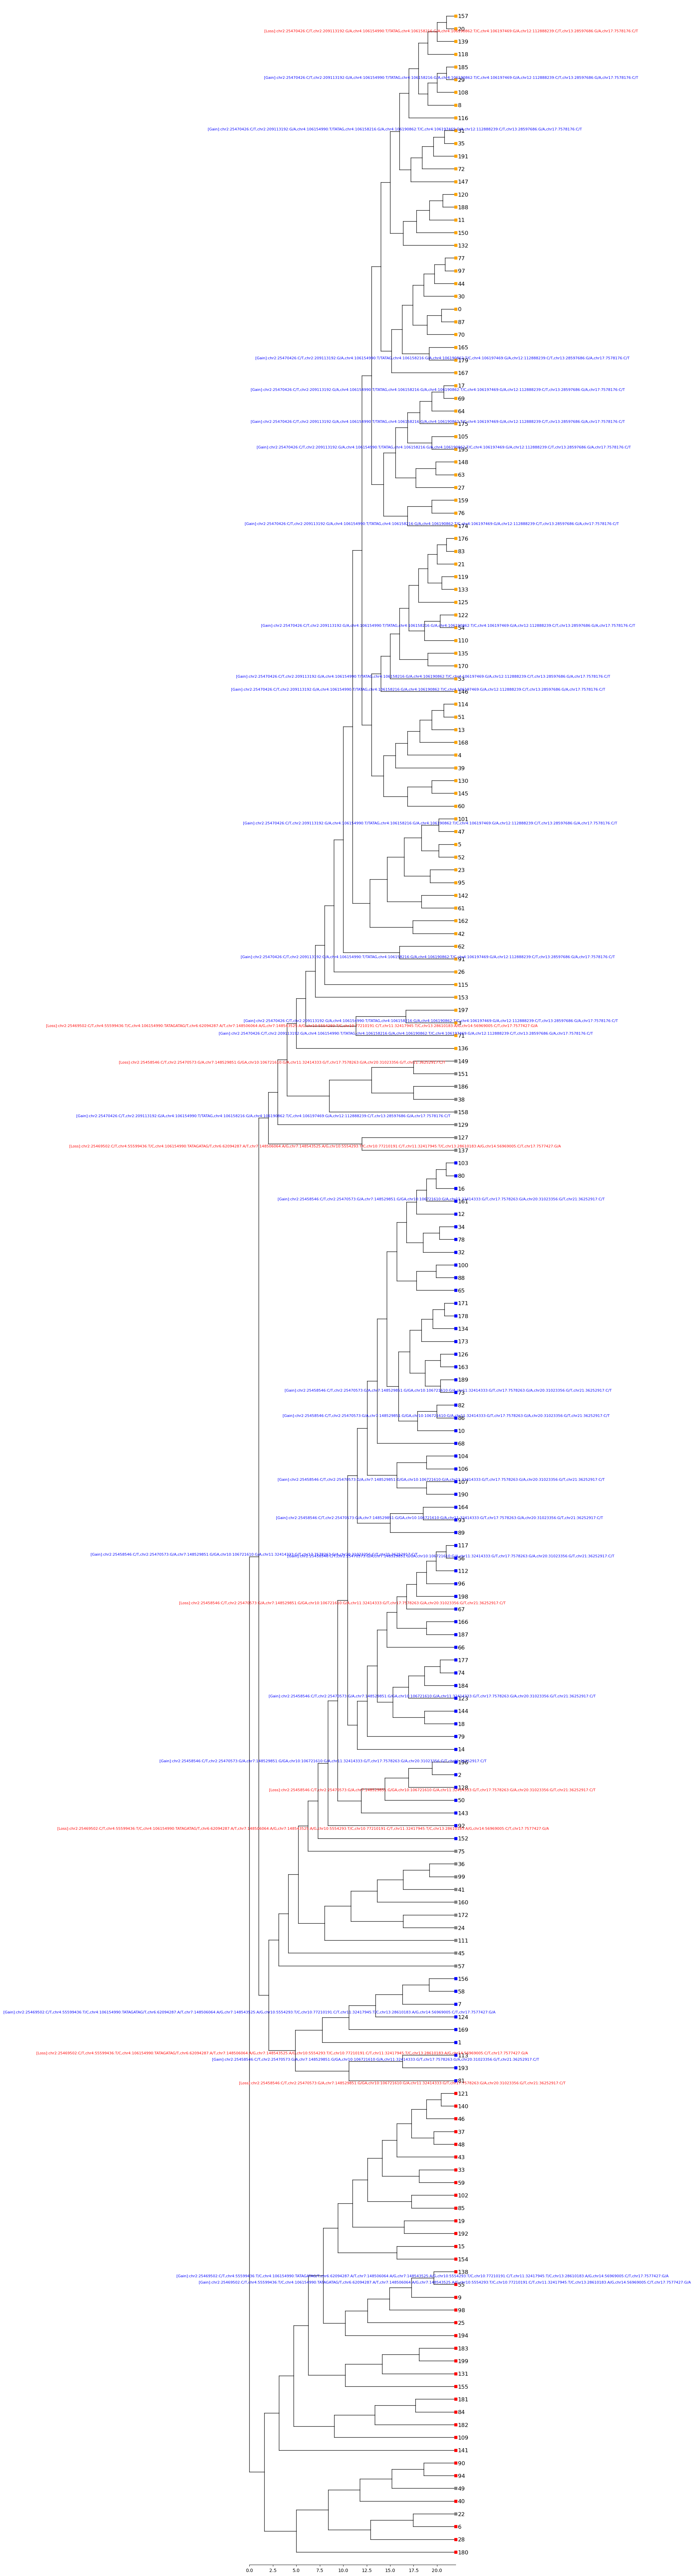

In [34]:
anns = sample.dna.get_annotations()
anns['gid'] = anns.apply(lambda x: x['Gene'] + ':' + x['Ref allele'] + ':' +  x['Alt allele'], axis=1)
# gene_mapping = {f'gene_{i}': gene for i, gene in enumerate(anns['gid'])}
gene_mapping = {f'gene_{i}': gene for i, gene in enumerate(anns.index)}

colors = {'Jurkat': 'blue', 'KG-1': 'orange', 'TOM-1': 'red', 'Mixed': 'grey'}
tv = TreeViz(decoded_tree.output())
traversor = popgen.utils.TraversalGenerator()
for node in traversor(decoded_tree):
    leaves = [leaf.name for leaf in node.get_leaves()]
    # print(node.events)
    if node.events['gain']:
        gain_annotation = '[Gain]:' + ','.join([gene_mapping[gene] for gene in node.events['gain']]) 
        tv.text_on_branch(leaves, gain_annotation, xpos='center', ypos='top', color='blue')
    if node.events['loss']:
        loss_annotation = '[Loss]:' + ','.join([gene_mapping[gene] for gene in node.events['loss']])
        tv.text_on_branch(leaves, loss_annotation, xpos='center', ypos='bottom', color='red')
# tv.show_branch_length(color='red', label_formatter=lambda v: f"#mut: {v:.2f}")
# tv.show_confidence(color='blue', label_formatter=lambda v: f"conf: {v:.2f}")

for leaf in decoded_tree.get_leaves():
    leaf = decoded_tree[leaf]
    label = sample.dna.row_attrs['label'][int(leaf.name)]
    tv.marker(leaf.name, marker="s", color=colors[label])


tv.show_scale_axis()
fig = tv.plotfig()

In [51]:
sample.cnv[sample.dna.barcodes('Jurkat'), :].layers['ploidy']

array([[2.09078472, 2.11333191, 1.62330103, ..., 3.0045251 , 2.33855511,
        2.27952184],
       [2.65659218, 1.81705961, 1.98448851, ..., 2.71495564, 2.91559287,
        2.38636853],
       [2.31513103, 1.9923075 , 2.32052392, ..., 2.32395007, 2.71005538,
        1.92920324],
       ...,
       [1.38742691, 2.26547987, 1.09372858, ..., 0.3242793 , 2.3181927 ,
        2.78665438],
       [1.81034239, 2.18827393, 2.0737822 , ..., 0.67634066, 1.38870666,
        1.15928893],
       [1.53461884, 1.39238729, 2.28531621, ..., 1.80686082, 2.14272035,
        0.46868368]])

In [43]:
# sample.cnv[sample.dna.barcodes('Jurkat'), :].heatmap(attribute='ploidy')
sample.cnv.plot_ploidy(cluster='Jurkat')
sample.cnv.plot_ploidy(cluster='KG-1')
sample.cnv.plot_ploidy(cluster='TOM-1')

In [73]:
cellphy_tree.output()

'((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((116,54),146),130),39),(133,31)),176),168),145),42),(174,83)),0),63),179),165),(105,148)),17),(((((153,87),(70,97)),195),64),27)),175),69),71),((((((((((157,188),(159,76)),11),51),(119,122)),114),((((118,170),125),((35,53),13)),147)),21),167),26)),3),62),60),((139,72),191)),61),91),5),95),142),4),(110,23)),132),135),47),(136,197)),101),(((((((120,150),29),8),((44,77),30)),20),108),185)),52),162),115),(158,38)),((149,186),151)),129),127),137),(((((((((((((((((((((((((((102,98),(194,55)),94),25),9),90),138),(((180,199),109),192)),140),141),((((((19,28),48),6),84),121),15)),85),154),40),((((33,59),49),182),183)),(((((37,46),22),131),43),181)),155),99),111),41),(172,45)),57),160),36),24),92),152)),75),163),78),(34,88)),(198,89)),((177,178),(74,79))),((((((((113,193),156),7),124),58),1),187),((((107,82),86),10),((123,66),112)))),((144,32),(16,196))),(((((169,81),173),50),100),126)),(((2,67),128),80)),((117,18),(171,65))),((106,134)

In [45]:
## to itol

import pandas as pd

# 1. DEFINE YOUR CLASS COLORS
# Add all your unique class names and their colors here.
# Use hex codes (like '#FF0000') for colors.
color_map = {
    'TOM-1': '#d62728', # red
    'Jurkat': '#1f77b4', # blue
    'KG-1': '#ff7f0e', # green
    'Mixed': '#AAAAAA'  # grey
    # ... add all your other classes
}

def output_to_itol_ann(nodes):
    output_itol_txt = "itol_anno.txt"
    # 4. GENERATE THE ANNOTATION FILE
    with open(output_itol_txt, 'w') as f:
        # --- Write Header ---
        f.write("DATASET_COLORSTRIP\n")
        f.write("SEPARATOR COMMA\n")
        f.write("DATASET_LABEL,Node Classes\n") # This is the title for the color column
        
        # --- Write Legend ---
        f.write("LEGEND_TITLE,Class Legend\n")
        legend_shapes = []
        legend_colors = []
        legend_labels = []
        
        for class_name, color in color_map.items():
            legend_shapes.append('1') # 1 = square
            legend_colors.append(color)
            legend_labels.append(class_name)

        f.write(f"LEGEND_SHAPES,{','.join(legend_shapes)}\n")
        f.write(f"LEGEND_COLORS,{','.join(legend_colors)}\n")
        f.write(f"LEGEND_LABELS,{','.join(legend_labels)}\n")
        
        # --- Write Data ---
        f.write("DATA\n")
        
        # Loop through your CSV rows and write the data
        for row in nodes:
            node_id, node_class = row
            color = color_map.get(node_class)
            
            if color:
                f.write(f"{node_id},{color}\n")
            else:
                print(f"Warning: No color found for class '{node_class}' in node '{node_id}'")

nodes = []
for leaf in decoded_tree.get_leaves():
    leaf = decoded_tree[leaf]
    label = sample.dna.row_attrs['label'][int(leaf.name)]
    nodes.append((leaf.name, label))

output_to_itol_ann(nodes)
    